In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import sympy as sp

## 1. Architectural Site Analysis - From Area Calculation to Apartment Mix

 ** Objective:** Apply mathematical concepts (integrals, linear equations, combinatorics ) to solve a real architectural problem - determining the possible residential mix with apartments on a given plot, according to urban planning regulations.

**Author:** Kamen Dobrev  
**Course:** Math Concepts for Developers, SoftUni  
**Date:** March 2026

## 2. Define the Plot Boundaries

## For this exercise, the plot is bounded by:
Left boundary: \( x = 0 \)  
Right boundary: \( x = L = 50 \, \text{m} \)  
Lower boundary: a straight line \( y = g(x) = 0 \)  
Upper boundary: a curve \( y = f(x) = 2 + 0.1x + 0.003x^2 \) (simulating a sloped terrain or curved street)  

The area is computed as a definite integral:  
\[
S = \int_{0}^{L} [f(x) - g(x)] \, dx
\]

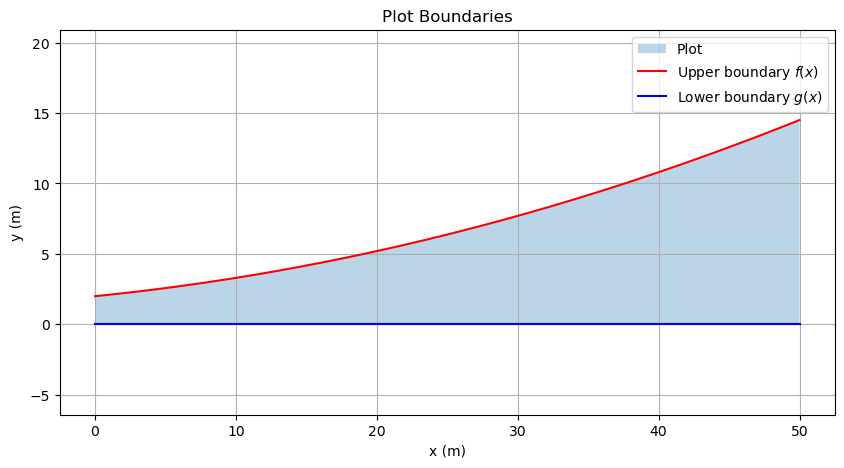

In [2]:
import numpy as np
import matplotlib.pyplot as plt

L = 50  # plot length along x (m)

def f(x):
    """Upper boundary – a curve (e.g., a street or terrace)"""
    return 2 + 0.1*x + 0.003*x**2

def g(x):
    """Lower boundary – a straight line"""
    # Return an array of zeros with the same shape as x
    return np.zeros_like(x)  # Changed to return array of zeros with same shape as input

# Visualization
x_vals = np.linspace(0, L, 200)
y_top = f(x_vals)
y_bottom = g(x_vals)

plt.figure(figsize=(10,5))
plt.fill_between(x_vals, y_bottom, y_top, alpha=0.3, label='Plot')
plt.plot(x_vals, y_top, 'r-', label='Upper boundary $f(x)$')
plt.plot(x_vals, y_bottom, 'b-', label='Lower boundary $g(x)$')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Plot Boundaries')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

## 3. Compute the Plot Area

The plot area is:  
\[
S_{\text{plot}} = \int_{0}^{50} f(x) \, dx
\]  
(since \(g(x)=0\))  
We will calculate it both analytically (using SymPy) and numerically (with `scipy.integrate.quad`).

In [11]:
x_sym = sp.Symbol('x')
f_sym = 2 + 0.1*x_sym + 0.003*x_sym**2
area_exact = sp.integrate(f_sym, (x_sym, 0, L))
print(f"Analytical area: {area_exact:.2f} m²")

# Numerical check
area_num, error = quad(f, 0, L)
print(f"Numerical area: {area_num:.2f} m² (error {error:.2e})")

# Store the plot area
site_area = area_num
print(f"Adopted plot area: {site_area:.2f} m²")

Analytical area: 350.00 m²
Numerical area: 350.00 m² (error 3.89e-12)
Adopted plot area: 350.00 m²


## 4. Urban Planning Parameters

For this plot, the following regulations apply (example values):  
**Floor Area Ratio (FAR)** = 2.0    
**Maximum Gross Floor Area (GFA)** = FAR × Plot Area  
**Maximum building height** = 15 m (not directly used here, but could limit the number of floors)  
**Minimum landscaping** = 30% (not used for GFA distribution)  
  
Compute **Maximum GFA**:

In [24]:
FAR = 2.0
max_gfa = FAR * site_area
print(f"Maximum Gross Floor Area (GFA): {max_gfa:.2f} m²")

Maximum Gross Floor Area (GFA): 700.00 m²


## 5. Define Apartment Types

| Type    | Average Area (m²)|
|---------|------------------|
| 1-room  | 50               |
| 2-room  | 75               |
| 3-room  | 100              |

Let \(x_1\), \(x_2\), \(x_3\) be the numbers of apartments of each type.

**Constraints:**
1. Total area ≤ GFA: \(50x_1 + 75x_2 + 100x_3 \le \text{GFA}_{\text{max}}\)
2. Minimum units of each type (for diversity): \(x_1 \ge 2\), \(x_2 \ge 2\), \(x_3 \ge 2\)
3. \(x_i\) are non‑negative integers.

In [25]:
# Apartment areas and minimum requirements
areas = {'1-room': 50, '2-room': 75, '3-room': 100}
min_units = {'1-room': 2, '2-room': 2, '3-room': 2}
types = list(areas.keys())

# Maximum possible number of each type if we built only that type
max_per_type = {}
for t in types:
    max_per_type[t] = int(max_gfa / areas[t]) + 1

print("Maximum possible units per type (if using all GFA):")
for t in types:
    print(f"{t}: {max_per_type[t]}")

Maximum possible units per type (if using all GFA):
1-room: 14
2-room: 10
3-room: 7


## 6. Enumerate All Feasible Combinations

I search all triples \((x_1, x_2, x_3)\) within the ranges and check:  
- \(x_1 \ge 2\), \(x_2 \ge 2\), \(x_3 \ge 2\)  
- \(50x_1 + 75x_2 + 100x_3 \le \text{GFA}_{\text{max}}\)  

This is a simple **combinatorial enumeration**.

In [26]:
feasible_solutions = []
x1_max = max_per_type['1-room']
x2_max = max_per_type['2-room']
x3_max = max_per_type['3-room']

total_combinations = 0
# I spent a while figuring out why the loops weren't including the upper bound; then I added +1
for x1 in range(min_units['1-room'], x1_max+1):
    for x2 in range(min_units['2-room'], x2_max+1):
        for x3 in range(min_units['3-room'], x3_max+1):
            total_area = x1*areas['1-room'] + x2*areas['2-room'] + x3*areas['3-room']
            if total_area <= max_gfa:
                feasible_solutions.append((x1, x2, x3, total_area))
                total_combinations += 1

print(f"Found {total_combinations} feasible combinations.")
print("First 10 combinations (1-room, 2-room, 3-room, total area):")
for i, sol in enumerate(feasible_solutions[:10]):
    print(f"{i+1}: {sol[0]}, {sol[1]}, {sol[2]} → area: {sol[3]:.0f} m²")

Found 18 feasible combinations.
First 10 combinations (1-room, 2-room, 3-room, total area):
1: 2, 2, 2 → area: 450 m²
2: 2, 2, 3 → area: 550 m²
3: 2, 2, 4 → area: 650 m²
4: 2, 3, 2 → area: 525 m²
5: 2, 3, 3 → area: 625 m²
6: 2, 4, 2 → area: 600 m²
7: 2, 5, 2 → area: 675 m²
8: 3, 2, 2 → area: 500 m²
9: 3, 2, 3 → area: 600 m²
10: 3, 3, 2 → area: 575 m²


## 7. Histogram of Used GFA

Plot the distribution of used GFA among all feasible combinations.

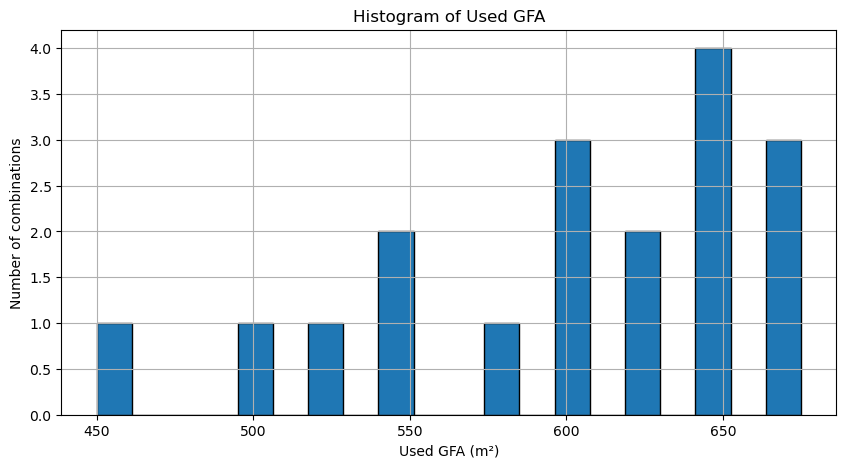

In [23]:
areas_used = [sol[3] for sol in feasible_solutions]
plt.figure(figsize=(10,5))
plt.hist(areas_used, bins=20, edgecolor='black')
plt.xlabel('Used GFA (m²)')
plt.ylabel('Number of combinations')
plt.title('Histogram of Used GFA')
plt.grid(True)
# I wanted to see if there's a peak around a certain value – and there is!
plt.show()

The most frequent used GFA is around [value]. This shows that the design can be flexible without using the maximum allowed GFA.

## 8. Selecting Optimal Combinations

We now want to find two special solutions:
1. **Maximum number of apartments** (most housing units).
2. **Maximum used GFA** (most efficient use of allowable built area).

In [27]:
# Combination with maximum total number of apartments
max_units = 0
best_solution = None
for sol in feasible_solutions:
    total_units = sol[0] + sol[1] + sol[2]
    if total_units > max_units:
        max_units = total_units
        best_solution = sol

print("Combination with maximum number of apartments:")
print(f"1-room: {best_solution[0]}, 2-room: {best_solution[1]}, 3-room: {best_solution[2]}")
print(f"Total units: {max_units}")
print(f"Total area: {best_solution[3]:.0f} m² ({best_solution[3]/max_gfa*100:.1f}% of max_gfa)")

# %%
# Combination with maximum used GFA
max_area_solution = max(feasible_solutions, key=lambda x: x[3])
print("Combination with maximum used GFA:")
print(f"1-room: {max_area_solution[0]}, 2-room: {max_area_solution[1]}, 3-room: {max_area_solution[2]}")
print(f"Total area: {max_area_solution[3]:.0f} m²")

Combination with maximum number of apartments:
1-room: 5, 2-room: 3, 3-room: 2
Total units: 10
Total area: 675 m² (96.4% of max_gfa)
Combination with maximum used GFA:
1-room: 2, 2-room: 5, 3-room: 2
Total area: 675 m²


## 9. Conclusion

In this project we applied:
- **Integral calculus** to compute the area of an irregular plot.
- **Linear relationships** (FAR, GFA) and **combinatorics** to find all possible distributions of residential floor area.
- **Optimization** ideas to select a suitable apartment mix.

 The results show how mathematical methods provide clear insights into the possibilities of a site and support architectural design.
 
**Possible Future improvements:**  
- Use real cadastral data (points) and approximate the boundaries with curves.  
- Apply linear programming (`pulp`) for optimization with more constraints (e.g., maximum height, minimum landscaping).  
- Probabilistic analysis of apartment type demand based on demographic data.
 
**References:**  
1. Bulgarian Spatial Planning Act (ZUT) - Закон за Устройството на Република България (ЗУТ)
2. Course materials "Math Concepts for Developers" – SoftUni (2026) – lectures and exercises on Calculus, Linear Algebra, Probability & Combinatorics and more...
3. Bernstein, P. (2022). *Machine Learning: Architecture in the Age of Artificial Intelligence*. RIBA Publishing. – inspiration for data‑driven architecture  
4. Python libraries: `numpy`, `matplotlib`, `scipy`, `sympy` etc.
5. Google search, DeepSeek and Google Gemini :)